# Background & Objectives

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They have the following question: what’s likely to make the employee leave the company?

Our goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company. 

In [87]:
# Locating datasets file

import os

print(f'Current working directory: {os.getcwd()}')

data_folder = os.path.join(os.getcwd(), 'data')

files = []

for dirname, _, filenames in os.walk(data_folder):
    for filename in filenames:
        filepath = os.path.join(dirname, filename)
        print(filepath)
        files.append(filepath)

datasets_path = os.path.join(files[0])

Current working directory: c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\data\data.csv


# Import Libraries

In [88]:
# Data manipulation libs
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

# ML Model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from xgboost import plot_importance

# Model Evaluation Metrics
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, log_loss
# Reporting
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.inspection import permutation_importance

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Utilities
import re

# 1. Initial Look

In [89]:
df0 = pd.read_csv(datasets_path)
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [90]:
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Based on the displayed dataframe
- No nulls detected
- Some feature may need to be encoded [`Department`, `salary`]
- Column names need to be normalized
- `left` is our target which is binary variable

In total there are 10 variables, with 8 numerical and 2 categorical variables.

In [91]:
# Copy the original dataframe
df = df0.copy()

# 2 Data Cleaning

## Column Names Normalization

In [92]:
# Begin by normalizing column names
df.columns = [x.lower() for x in df0.columns]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


## Duplicate Removal

In [93]:
# Check for duplicates
df.duplicated().sum()

np.int64(3008)

3000 or about 20% of the rows is considered duplicate.

In [94]:
# Removing duplicates
df = df.drop_duplicates()
df.shape

(11991, 10)

- Nulls and duplicates has been handled.
- All variable is casted to their appropriate type.

proceeding to EDA

# 3. EDA

## Big Picture

### Descriptive Statistics

In [95]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Check Outliers

In [96]:
viz_df = df.drop(['salary', 'department'], axis=1)

c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


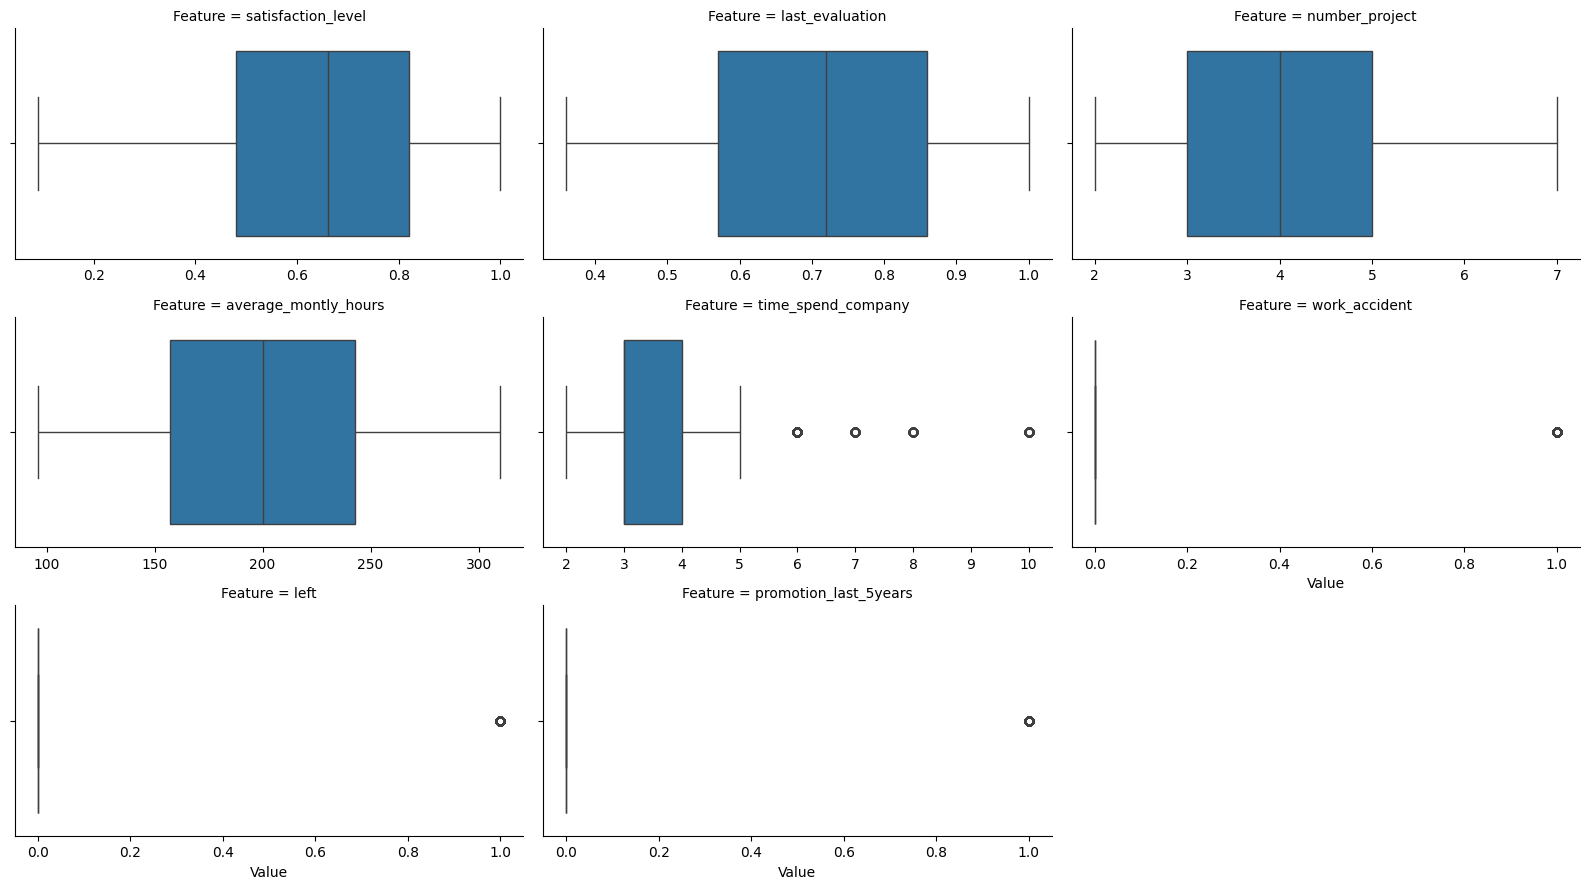

In [97]:
df_long = viz_df.melt(var_name = 'Feature', value_name = 'Value')
grid = sns.FacetGrid(df_long, col='Feature', col_wrap=3, sharex=False, aspect=16 / 9, height=3)
grid.map(sns.boxplot, "Value")

plt.show()

`time_spend_company` appears to contains some outliers

### Correlation

In [98]:
# R^2 with target variable sorted from the most significant to the less
corr_w_target = viz_df.drop('left', axis=1).corrwith(df['left']) ** 2
corr_w_target.sort_values(ascending=False).round(3)

satisfaction_level       0.123
time_spend_company       0.030
work_accident            0.016
average_montly_hours     0.005
promotion_last_5years    0.002
number_project           0.001
last_evaluation          0.000
dtype: float64

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\1390788717.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


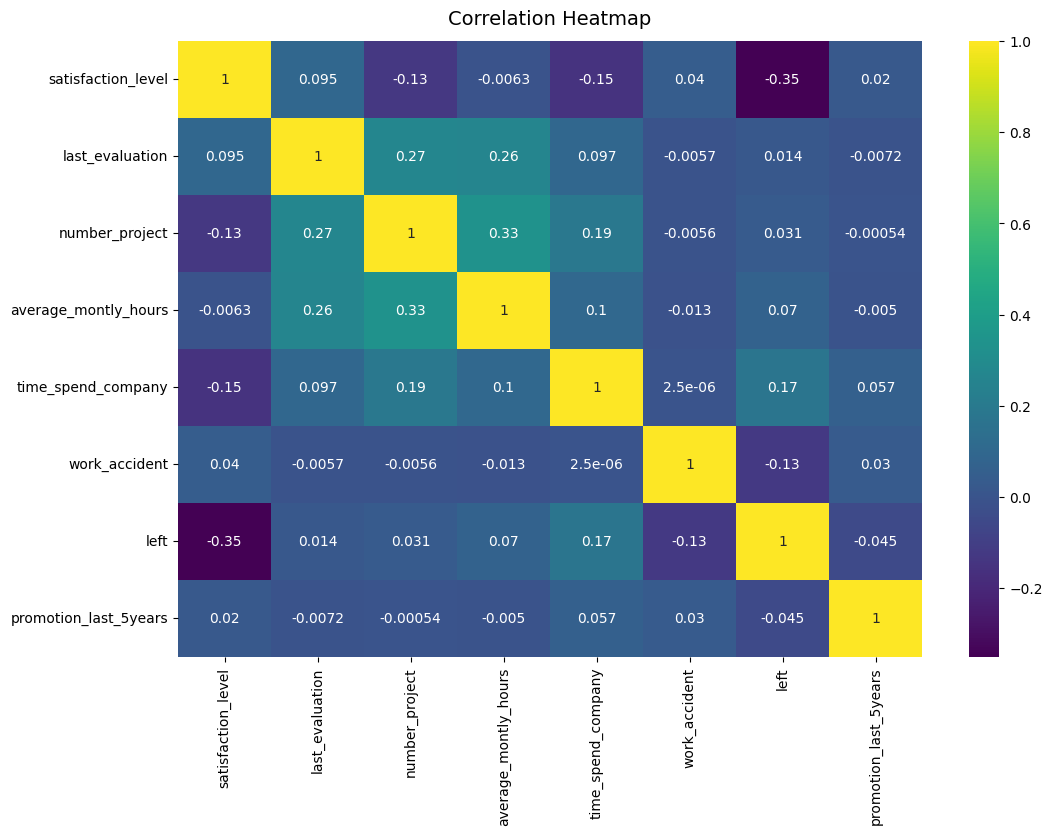

In [99]:
fig, ax = plt.subplots(figsize=(12, 8))

hm = sns.heatmap(df.drop(['department', 'salary'], axis=1).corr(), annot=True, cmap='viridis', ax=ax)

ax.set_title('Correlation Heatmap', fontdict={'fontsize': 14}, pad = 12)
fig.show()

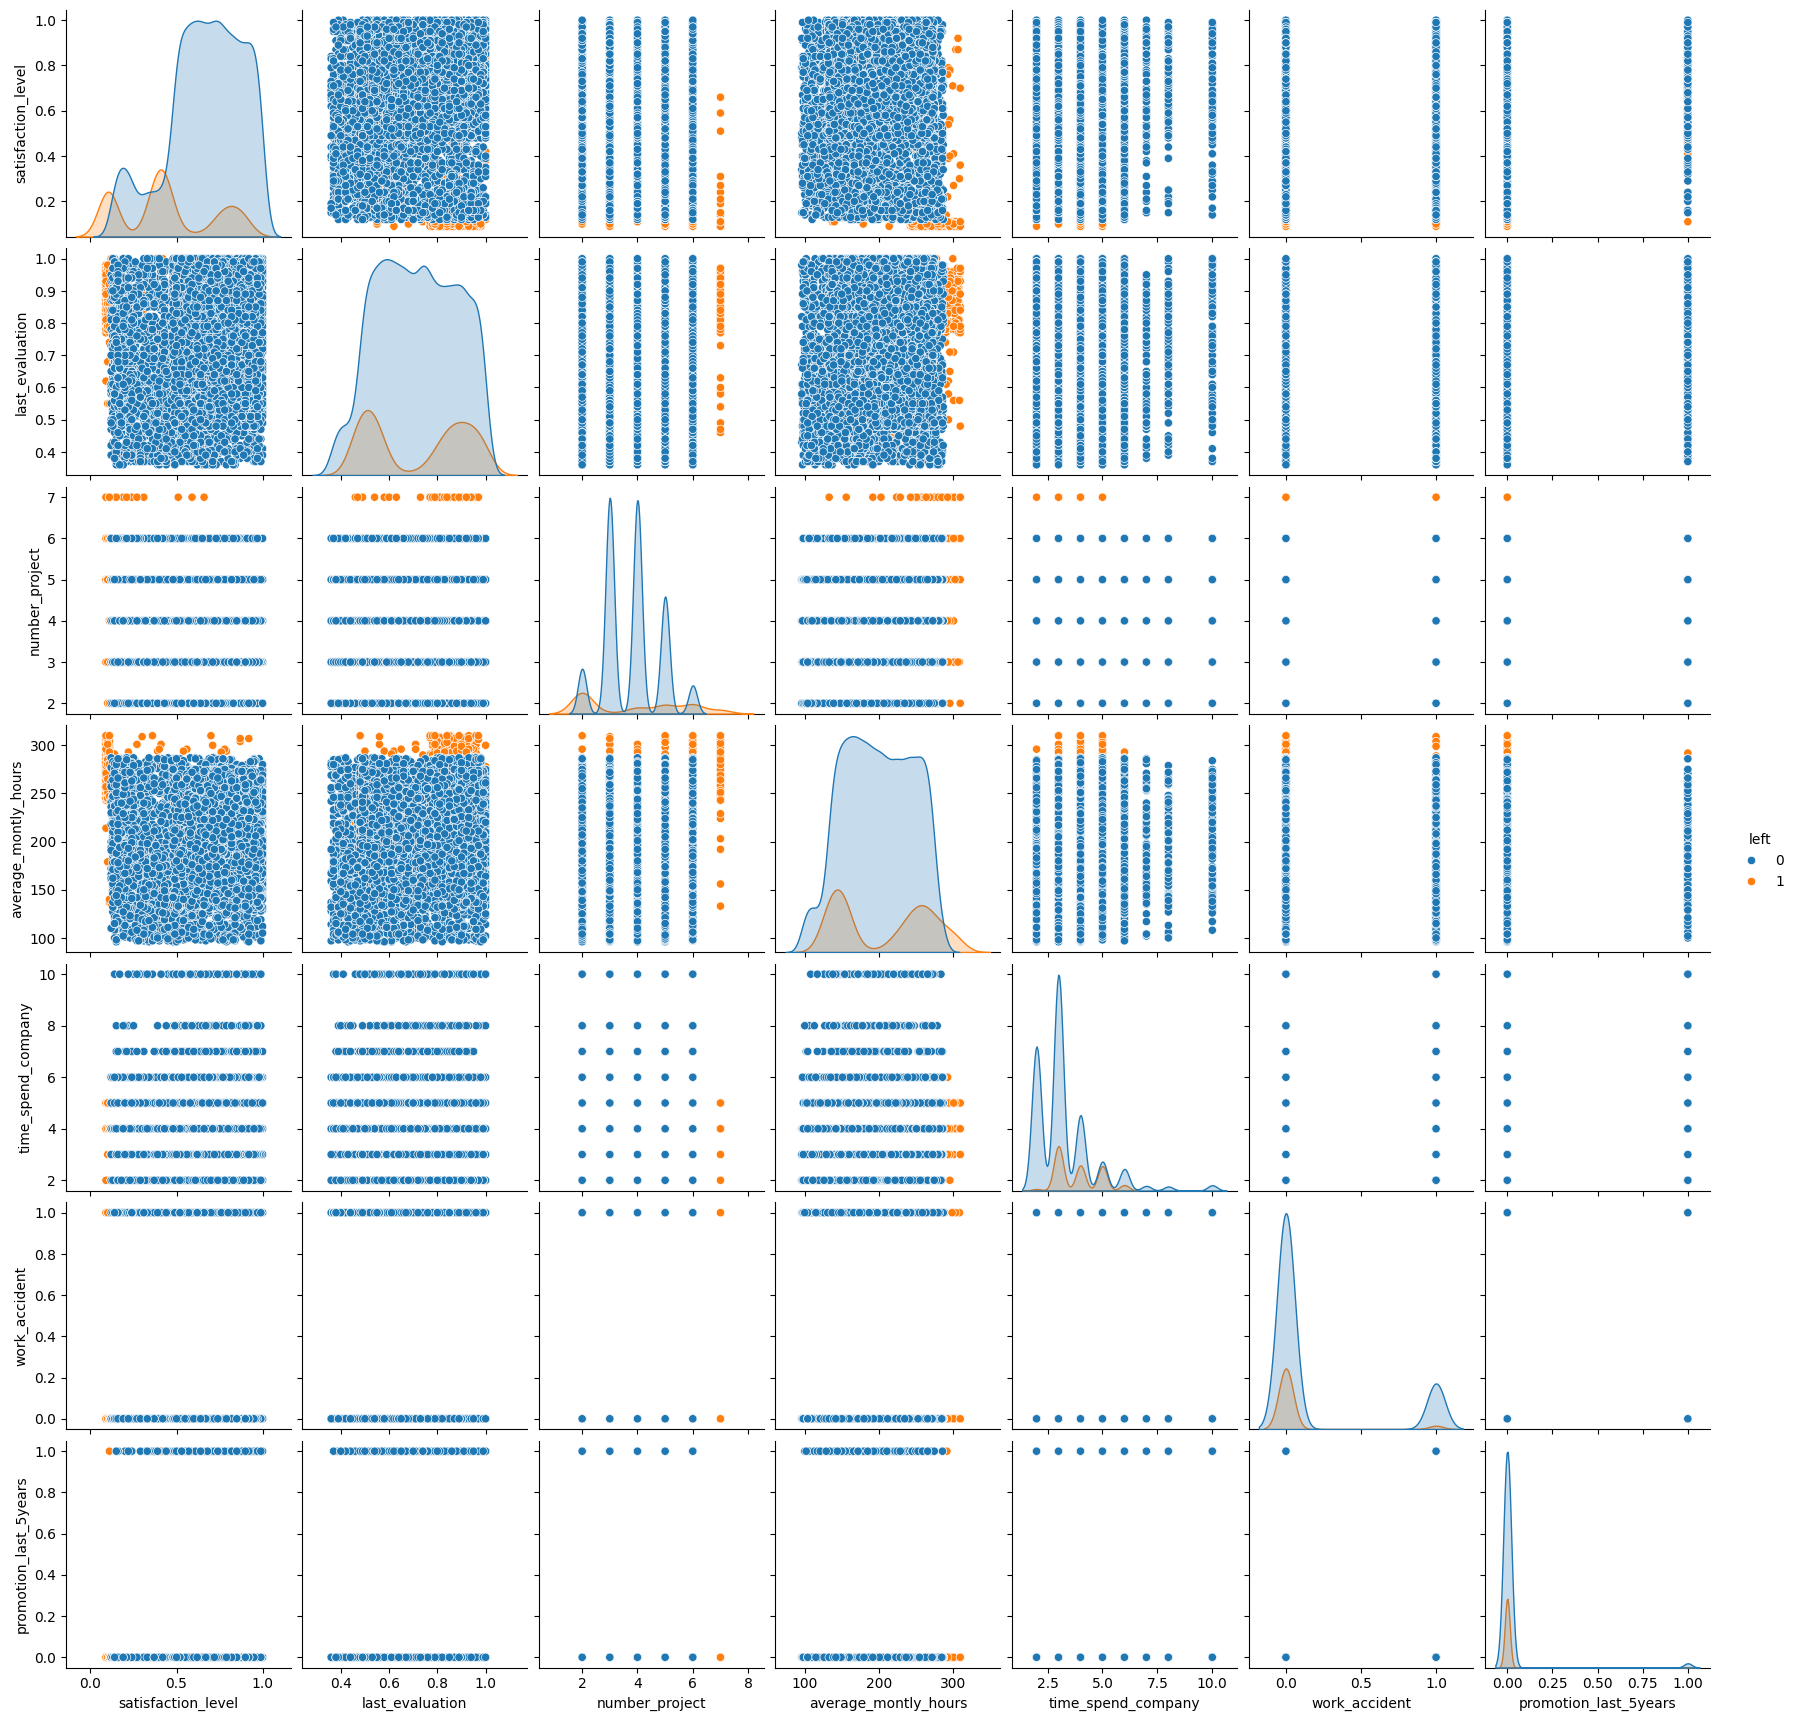

In [100]:
sns.pairplot(viz_df, hue='left')

### Check Target Class Balance

In [101]:
df['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

<Axes: title={'center': 'Stay vs Leave'}>

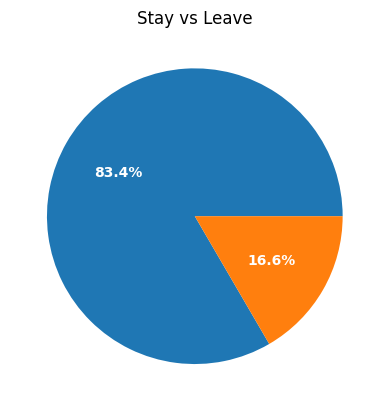

In [102]:
df['left'].value_counts().plot(kind='pie', labels=['Stay', 'Leave'], title='Stay vs Leave', autopct='%.1f%%', textprops={'color':'w', 'weight':'bold'})

There is class imbalance on the target variable

### Insight Summary

From the correlation coefficient alone, these variables play role to determine employee turnover
1. satisfaction_level
2. time_spend_company
3. work_accident
4. salary
5. average_montly_hours

In the Pairplot visualization there seems to be pattern emerging revolving `avg_montly_hours`, `number_of_project` and `last_evaluation`, employee who overworked more likely to quit, while the number of project could directly contributed to the number of hours employee work. Moreover, despite `satisfaction_level` being the number 1 of the most contributed factor in determining employee turnover, it seems this variable is a derivative from another variable like `avg_monthly_hours` or `number_of_project`.

### Next Step

Perform joint visualization between `avg_montly_hours`, `number_project`, `last_evaluation` and `satisfaction_level`

## Left by Avg. Work Hours and Project

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\294044059.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


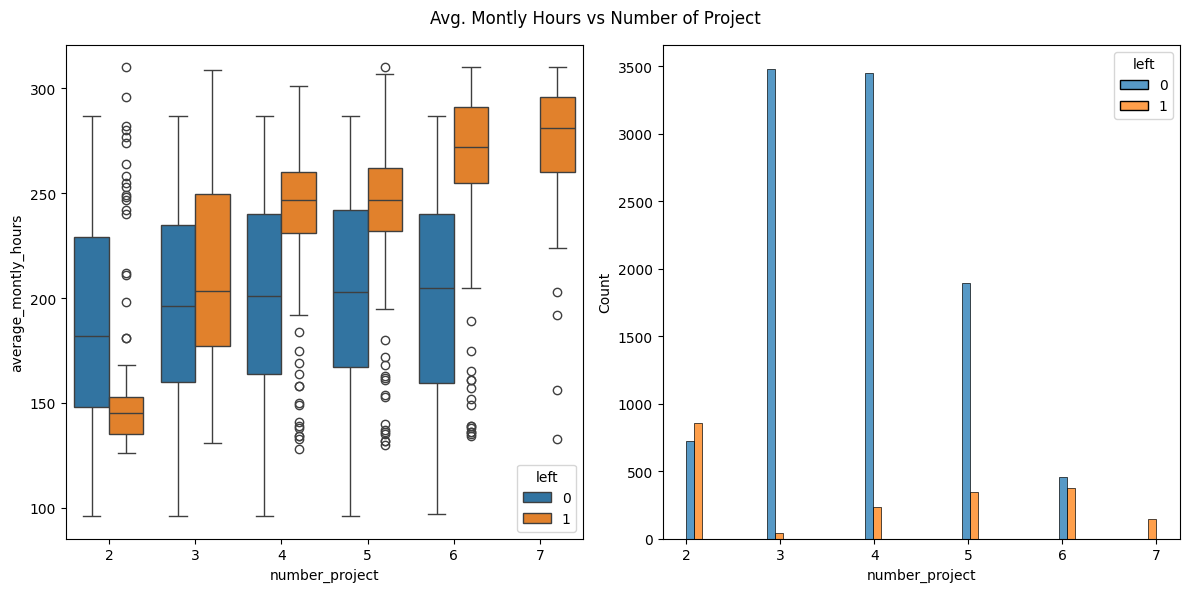

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data = viz_df, y='average_montly_hours', x='number_project', hue='left', ax=axes[0])
sns.histplot(data = viz_df, x='number_project', hue='left', ax=axes[1], multiple='dodge')

fig.suptitle('Avg. Montly Hours vs Number of Project')
fig.tight_layout()
fig.show()

Based on above observation we can take there are two kinds of turnover happening:
1. Employee who overworked and quit
2. Employee who have normal work hours and quit

The optimal project for the least turnover is 3.

In [104]:
summary_by_project = viz_df.groupby('number_project').agg(avg_monthly_hours = ('average_montly_hours', 'mean'), emp_count = ('left', 'count'), total_leave = ('left', 'sum'))
summary_by_project = summary_by_project.reset_index()
summary_by_project['avg_hours_per_day'] = summary_by_project['avg_monthly_hours'] / 22 # Assuming 5 days a week workday.
summary_by_project['left_percent'] = summary_by_project['total_leave'] / summary_by_project['emp_count']
summary_by_project = summary_by_project.drop(columns = ['emp_count', 'total_leave'])

styles = {
    'left_percent': '{:.0%}',
    'avg_hours_per_day': '{:.1f} Hours',
    'avg_monthly_hours': '{:.0f} Hours'
}


summary_by_project.style.format(styles)

,number_project,avg_monthly_hours,avg_hours_per_day,left_percent
0,2,165 Hours,7.5 Hours,54%
1,3,197 Hours,9.0 Hours,1%
2,4,204 Hours,9.3 Hours,6%
3,5,209 Hours,9.5 Hours,15%
4,6,230 Hours,10.5 Hours,45%
5,7,276 Hours,12.5 Hours,100%


Above table confirms that all employees who took project greater than 6 eventually leave.

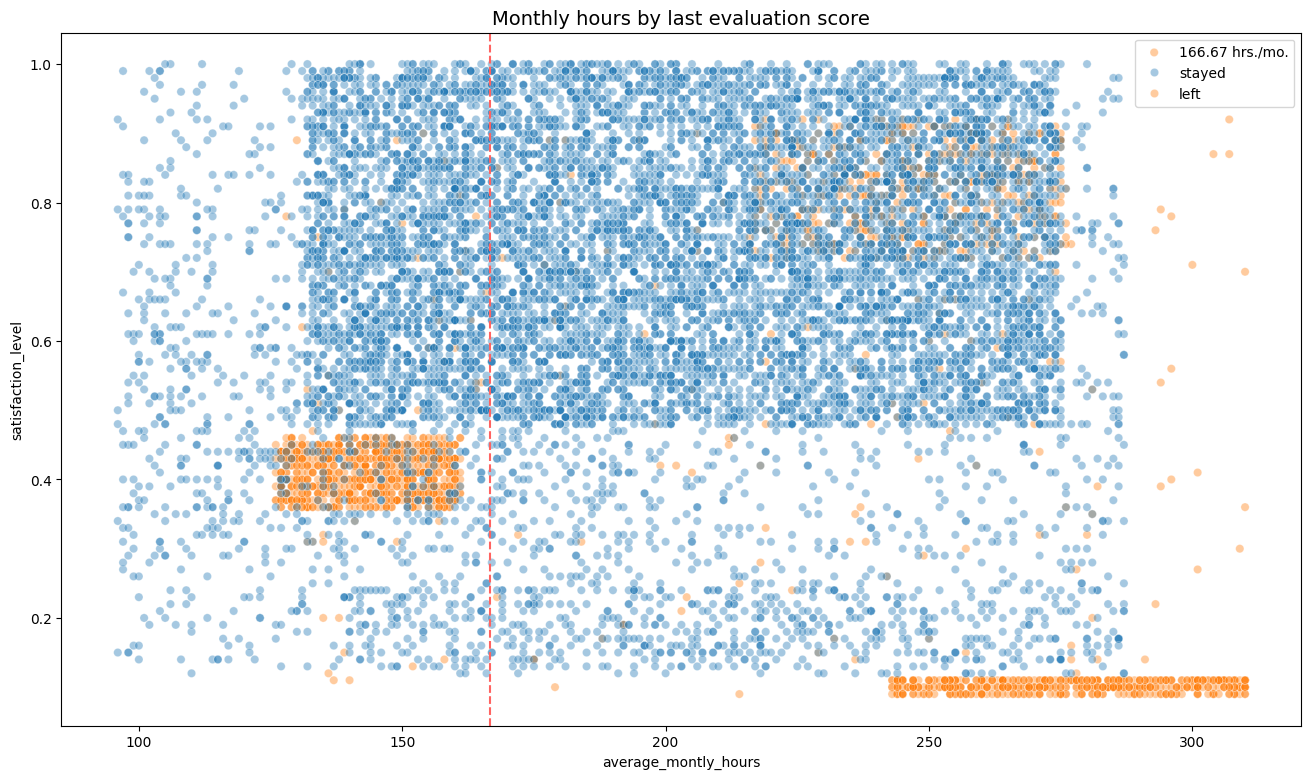

In [105]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=viz_df, x='average_montly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'stayed', 'left'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

The scatterplot above shows that a large portion of the employees worked above 166 hours (8 hours / day). And a sizeable group of employees who worked ~240-315 hours per month. 315 hours per month is over 75 hours per week for a whole year. it's likely this is related to their satisfaction level being close to zero.

Another group who left have normal working hours (<166h) having lesser satisfaction level. It's difficult to say why they might left. It's possible they pressured to work more because their peers does.

And then there's the third group who worked ~210-280 hours per month, and they had satisfaction levels ranging ~0.7-0.9.

## Left by Satisfaction Score

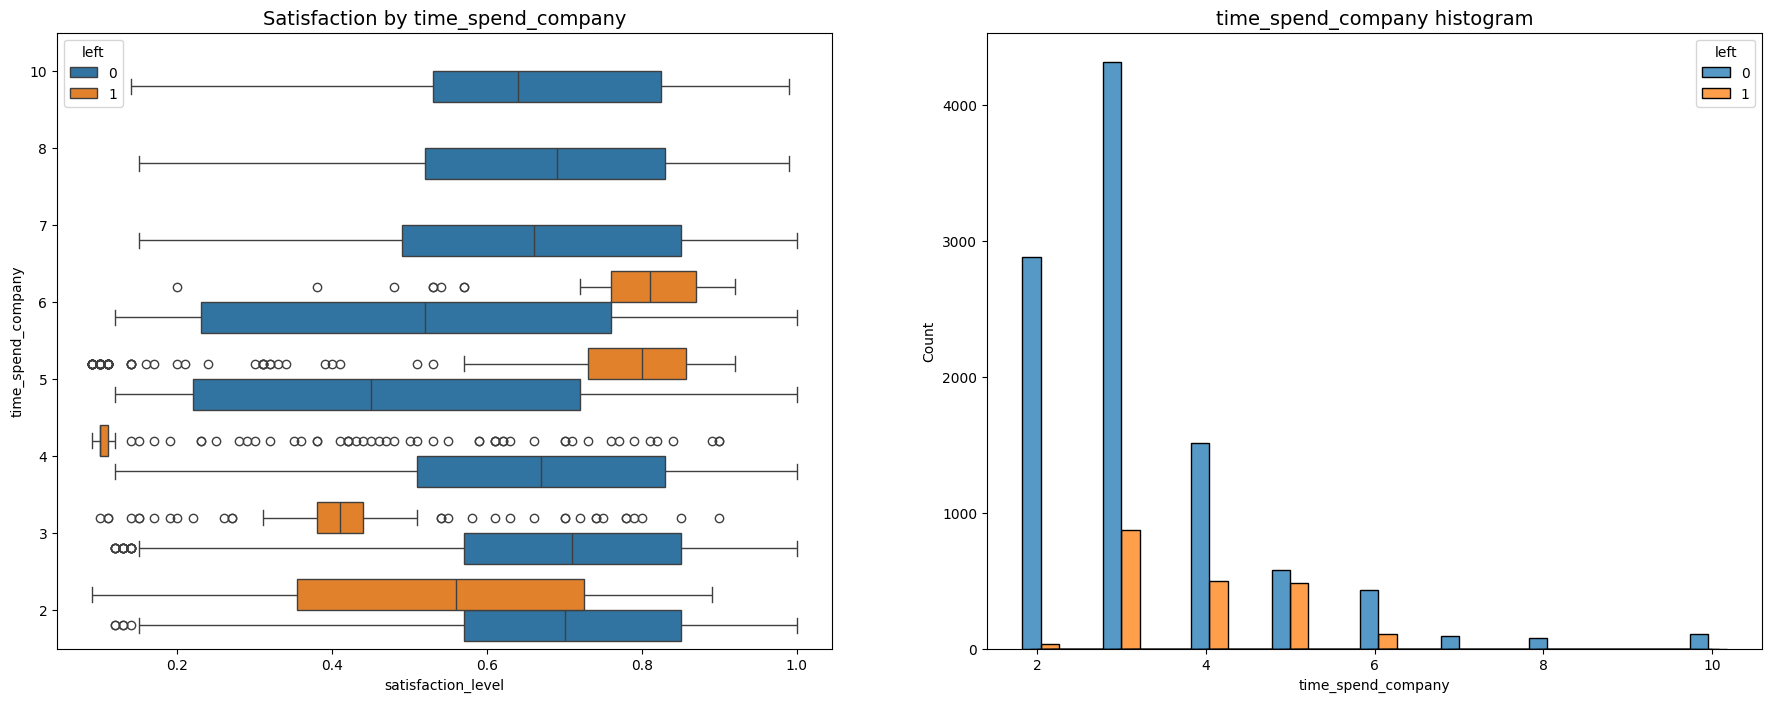

In [106]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

sns.boxplot(data=viz_df, x='satisfaction_level', y='time_spend_company', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by time_spend_company', fontsize='14')

tenure_stay = viz_df[viz_df['left']==0]['time_spend_company']
tenure_left = viz_df[viz_df['left']==1]['time_spend_company']
sns.histplot(data=viz_df, x='time_spend_company', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('time_spend_company histogram', fontsize='14')

plt.show();

#### Insights:
- Employees who left fall into two general categories: dissatisfied employees with shorter tenures and very satisfied employees with medium-length tenures.
- Four-year employees who left seem to have an unusually low satisfaction level. It's worth investigating changes to company policy that might have affected people specifically at the four-year mark, if possible. 
- The longest-tenured employees didn't leave. Their satisfaction levels aligned with those of newer employees who stayed. 
- The histogram shows that there are relatively few longer-tenured employees. It's possible that they're the higher-ranking, higher-paid employees.

In [107]:
viz_df.groupby('left')['satisfaction_level'].agg(['mean', 'median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, among employees who stayed, the mean satisfaction score appears to be slightly below the median score. This indicates that satisfaction levels among those who stayed might be skewed to the left. 

## Left by Tenure

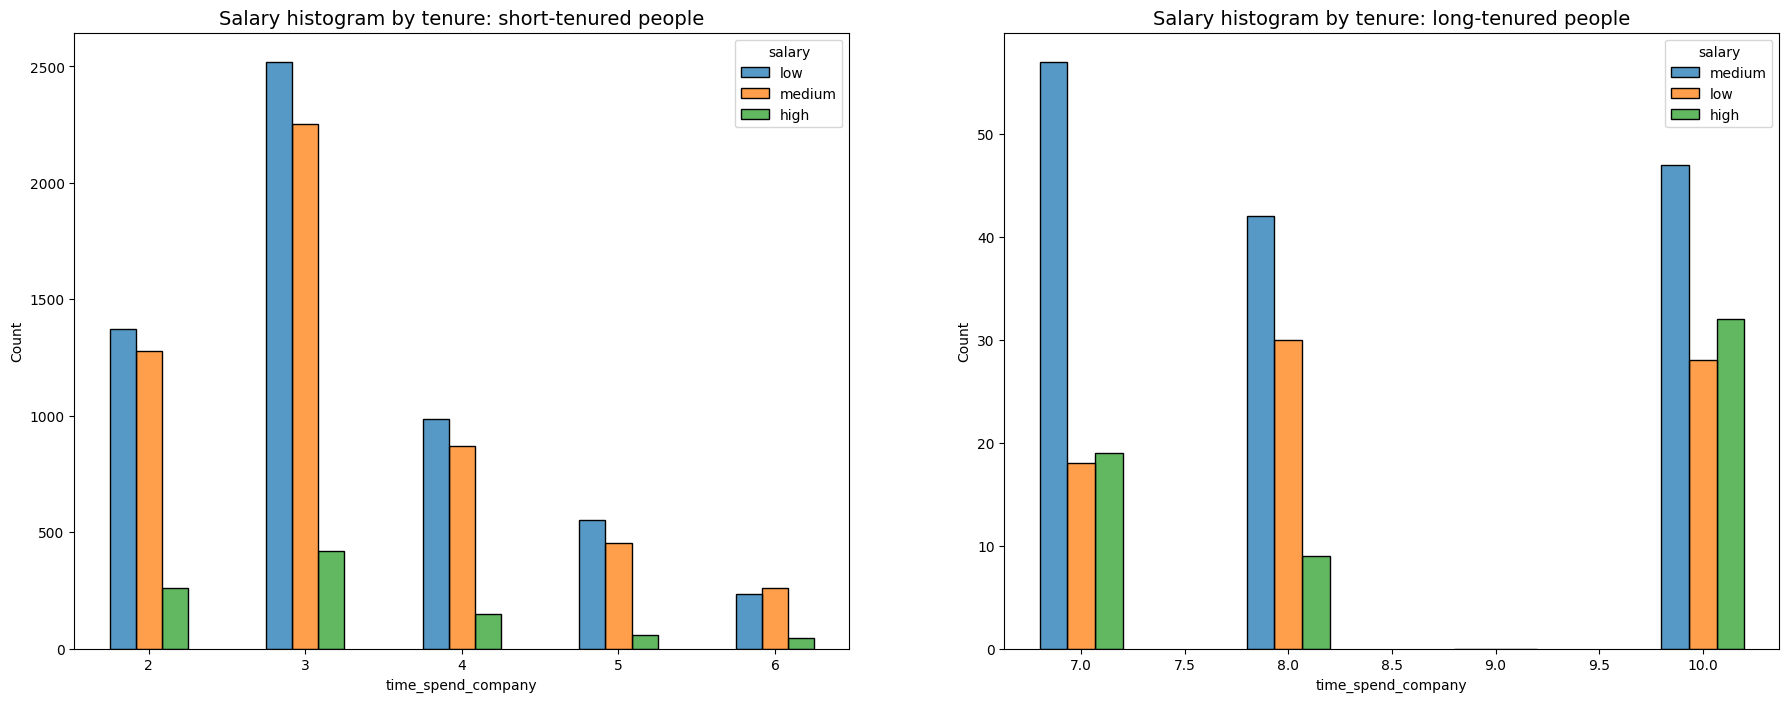

In [108]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

tenure_short = df[df['time_spend_company'] < 7]

tenure_long = df[df['time_spend_company'] > 6]

sns.histplot(data=tenure_short, x='time_spend_company', hue='salary', discrete=1, multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

sns.histplot(data=tenure_long, x='time_spend_company', hue='salary', discrete=1, multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

The plots above show that long-tenured employees were not disproportionately comprised of higher-paid employees. 

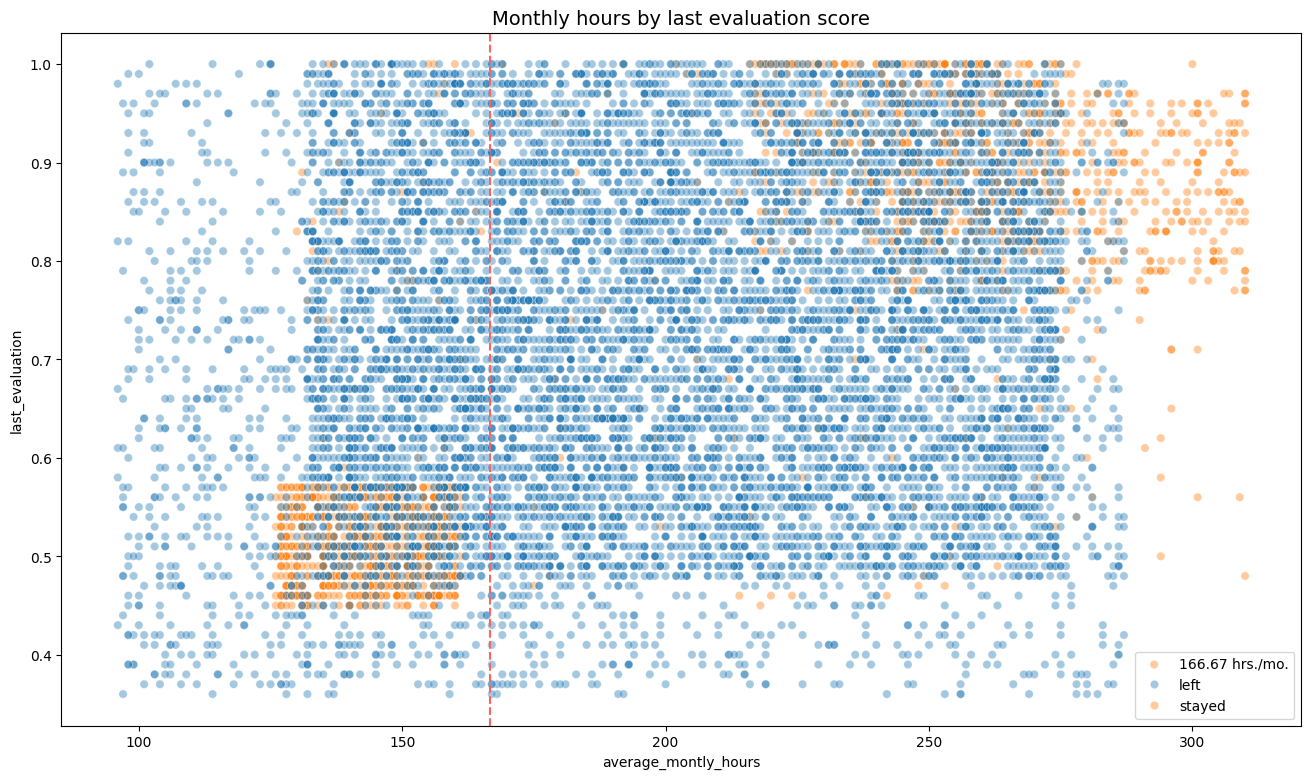

In [109]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=viz_df, x='average_montly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

#### Insights:

- The scatterplot indicates two groups of employees who left: overworked employees who performed very well and employees who worked slightly under the nominal monthly average of 166.67 hours with lower evaluation scores. 
- There seems to be a correlation between hours worked and evaluation score. 
- There isn't a high percentage of employees in the upper left quadrant of this plot; but working long hours doesn't guarantee a good evaluation score.
- Most of the employees in this company work well over 167 hours per month.

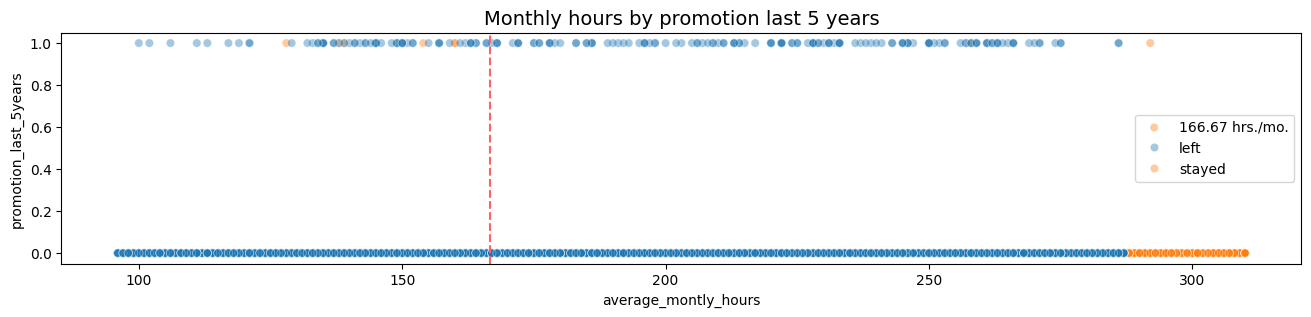

In [110]:
plt.figure(figsize=(16, 3))
sns.scatterplot(data=viz_df, x='average_montly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

#### Insights:

- very few employees who were promoted in the last five years left
- very few employees who worked the most hours were promoted
- all of the employees who left were working the longest hours  

## Left by Department

In [111]:
df["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

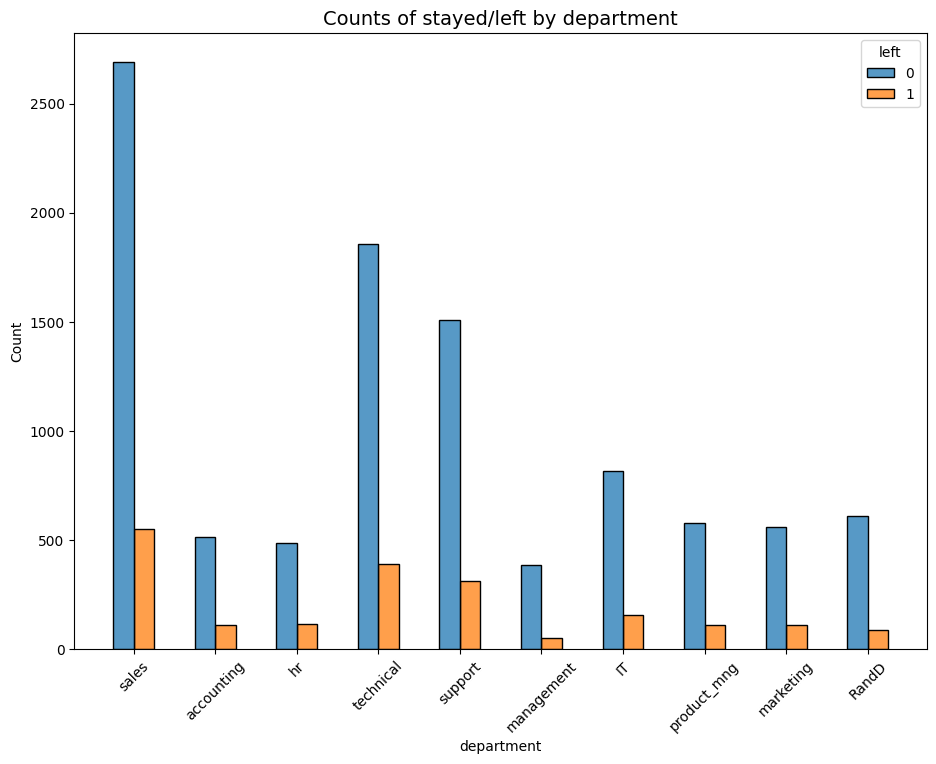

In [112]:
plt.figure(figsize=(11,8))
sns.histplot(data=df, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);

There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed. 

## Conclusion

It appears that employees are leaving the company as a result of poor management. Leaving is tied to longer working hours, many projects, and generally lower satisfaction levels. It can be ungratifying to work long hours and not receive promotions or good evaluation scores. There's a sizeable group of employees at this company who are probably burned out. It also appears that if an employee has spent more than six years at the company, they tend not to leave.

# 4. Feature Selection & Engineering

## Feature Encoding

### One Hot Encode department

Department is multinomial variable, therefore, we will performing one hot encoding for this feature.

In [113]:
df_enc = pd.get_dummies(df, columns=['department'], drop_first=False, dtype=int)
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,low,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,medium,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,medium,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,low,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,low,0,0,0,0,0,0,0,1,0,0


### Convert salary into ordinal variable

`salary` is ordinal variable, we will encode it as ordinal numeric variable with the following order
- high = 2
- medium = 1
- low = 0

In [114]:
df_enc['salary'] = df['salary'].astype('category').cat.set_categories(['low', 'medium', 'high']).cat.codes
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [115]:
df_enc.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_montly_hours    11991 non-null  int64  
 4   time_spend_company      11991 non-null  int64  
 5   work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5years   11991 non-null  int64  
 8   salary                  11991 non-null  int8   
 9   department_IT           11991 non-null  int64  
 10  department_RandD        11991 non-null  int64  
 11  department_accounting   11991 non-null  int64  
 12  department_hr           11991 non-null  int64  
 13  department_management   11991 non-null  int64  
 14  department_marketing    11991 non-null  int64  
 15  d

## is_overworked Feature

We will create feature called `is_overworked`, the calculation being:
- If employee worked 20% more on average than their department average monthly hours then 1 else 0

For example, department `A` average daily working hours is 8 hours, if an employee worked on average 10 hours a day, then it is considered overworked.

In [116]:
df_tr = df_enc.copy()
df_tr['dept_avg_work_hours'] = df.groupby('department')['average_montly_hours'].transform('mean')
df_tr['is_overworked'] = (df_tr['average_montly_hours'] > df_tr['dept_avg_work_hours']).astype(int)
df_tr = df_tr.drop(['dept_avg_work_hours'], axis=1)
df_tr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,is_overworked
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,2,0,0,0,0,1,0,0,0,0,0,1
11996,0.74,0.95,5,266,10,0,0,1,2,0,0,0,0,1,0,0,0,0,0,1
11997,0.85,0.54,3,185,10,0,0,1,2,0,0,0,0,1,0,0,0,0,0,0
11998,0.33,0.65,3,172,10,0,0,1,2,0,0,0,0,0,1,0,0,0,0,0


## Remove outliers

In [117]:
def get_col_outliers_by_iqr(df: pd.DataFrame, colname: str):
    """
    Given a DataFrame and column name, it will automatically remove outliers using Interquantile range technique
    """
    data = df[colname]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    bot_thres = q1 - iqr * 1.5
    top_thres = q3 + iqr * 1.5
    return ((data > top_thres) | (data < bot_thres))

In [118]:
df_tr = df_tr[~get_col_outliers_by_iqr(df_tr, 'time_spend_company')]
df_tr = df_tr.reset_index(drop=True)
df_tr.shape

(11167, 20)

# 5. Model Construction

We will start a from simple model and then gradually move into more complex model while checking each model feature importances.

In [119]:
# Helper for result making
class TestResult():
    def __init__(self):
        self._results = pd.DataFrame(columns=['model_name', 'precision', 'recall', 'f1', 'roc_auc', 'model'])

    @property
    def results(self):
        return self._results

    @results.setter
    def results(self, value):
        if(not isinstance(value, pd.DataFrame)):
            raise ValueError("Result value be instance of DataFrame")
        self._results = value
    
    def make_test_result(self, model_name: str, model: sklearn.base.BaseEstimator, X: pd.DataFrame, y: pd.Series):
        y_pred = model.predict(X)
        precision = precision_score(y, y_pred)
        recall = recall_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        roc_auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
        cols = ['model_name', 'precision', 'recall', 'f1', 'roc_auc', 'model']

        res = pd.DataFrame([[model_name, precision, recall, f1, roc_auc, model]], columns=cols)
        self._upsert_test_result(res)
        return res

    def _upsert_test_result(self, res: pd.DataFrame):
        self._results = pd.concat([self.results, res], axis = 0).drop_duplicates(subset=['model_name'], keep='last')
        self._results.reset_index(inplace=True, drop=True)

# Helper for reporting
class BaseReporter:
    def __init__(self, model, X, y):
        self.model = model
        self.X = X
        self.y = y

    def make_report(self):
        y_pred = self.model.predict(self.X)
        print(classification_report(self.y, y_pred))

        model_roc_score = roc_auc_score(self.y, self.model.predict_proba(self.X)[:, 1])
        model_log_loss = log_loss(self.y, self.model.predict_proba(self.X)[:, 1])
        recall = recall_score(self.y, y_pred)
        precision = precision_score(self.y, y_pred)
        
        print('ROC AUC Score: ', model_roc_score)
        print('Log Loss: ', model_log_loss)
        print('Recall: ', recall)
        print('Precision: ', precision)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot Confusion Matrix
        cm = confusion_matrix(self.y, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Stay', "Left"])
        disp.plot(ax=axes[0])

        # Plot ROC AUC
        tpr, fpr, thres = roc_curve(self.y, self.model.predict_proba(self.X)[:, 1])
        axes[1].plot(tpr, fpr)
        axes[1].set_title('ROC AUC Curve ' + f'({model_roc_score:.2f})')

        fig.tight_layout()
        fig.show()

class LinearReporter(BaseReporter):
    def __init__(self, model, X, y):
        super().__init__(model, X, y)
    
    def make_report(self):
        coefficients = self.model.coef_
        fp = pd.DataFrame(coefficients, columns=self.model.feature_names_in_).unstack().sort_values(ascending=False)
        print('\nFeature coefficients: \n', fp)
        super().make_report()

class NBReporter(BaseReporter):
    def __init__(self, model, X, y):
        super().__init__(model, X, y)
    
    def make_report(self):
        feature_importance = permutation_importance(self.model, self.X, self.y).importances_mean
        fp_df = pd.DataFrame(feature_importance, index=self.X.columns, columns=['score']).sort_values(by='score', ascending=False)
        print('\nFeature importances: \n', fp_df)
        super().make_report()

class TreeReporter(BaseReporter):
    def __init__(self, model, X, y):
        super().__init__(model, X, y)

    def make_report(self):
        feature_importance = self.model.feature_importances_
        fp_df = pd.DataFrame(feature_importance, index=self.X.columns, columns=['score']).sort_values(by='score', ascending=False)
        print('\nFeature importances: \n', fp_df)
        super().make_report()

test_results = TestResult()

## Training Test Split

We will split the data into 60 - 20 - 20, where:
- 60% goes into training
- 20% validation
- 20% test

In [120]:
X = df_tr.drop('left', axis=1)
y = df_tr['left']

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y) # Don't forget to stratify for imbalanced class
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train) # Don't forget to stratify for imbalanced class

In [122]:
# Verify shape
X_train.shape, X_test.shape, X_val.shape

((8933, 19), (2234, 19), (2234, 19))

## Linear Model

### Logistic Regression

In [123]:

logreg_clf = LogisticRegression(max_iter=1000)
logreg_clf.fit(X_tr, y_tr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


Feature coefficients: 
 time_spend_company      0    0.963374
department_hr           0    0.134526
department_technical    0    0.089032
department_support      0    0.065307
department_sales        0    0.045665
average_montly_hours    0    0.004193
last_evaluation         0    0.003025
department_management   0   -0.012348
department_marketing    0   -0.056927
is_overworked           0   -0.090086
department_product_mng  0   -0.104470
department_IT           0   -0.152079
department_accounting   0   -0.167157
number_project          0   -0.453960
promotion_last_5years   0   -0.471945
salary                  0   -0.516551
department_RandD        0   -0.616852
work_accident           0   -1.327669
satisfaction_level      0   -4.465032
dtype: float64
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1858
           1       0.51      0.26      0.34       376

    accuracy                           0.83      2234
   macro avg       0

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\334076621.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


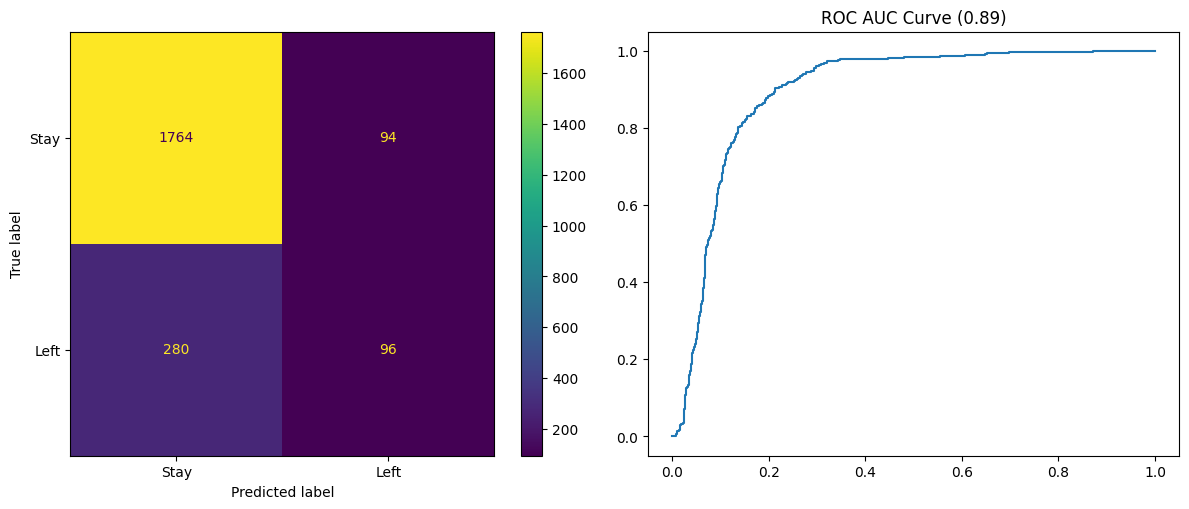

In [124]:
LinearReporter(logreg_clf, X_val, y_val).make_report()

In [125]:
test_results.make_test_result('Logistic Regression', logreg_clf, X_test, y_test)

,model_name,precision,recall,f1,roc_auc,model
0,Logistic Regression,0.489691,0.251989,0.33275,0.891394,LogisticRegression(max_iter=1000)


## Naive Bayes Model

### Gaussian Naive Bayes


Feature importances: 
                            score
satisfaction_level      0.066697
number_project          0.046643
time_spend_company      0.035631
work_accident           0.018711
salary                  0.010564
average_montly_hours    0.006714
last_evaluation         0.005013
department_RandD        0.002686
department_technical    0.001432
department_sales        0.000985
department_IT           0.000806
department_hr           0.000627
department_marketing    0.000537
department_support      0.000358
promotion_last_5years   0.000358
is_overworked           0.000269
department_management  -0.000179
department_product_mng -0.000537
department_accounting  -0.000716
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1858
           1       0.57      0.75      0.65       376

    accuracy                           0.86      2234
   macro avg       0.76      0.82      0.78      2234
weighted avg       0.88      0.86      0.87 

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\334076621.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


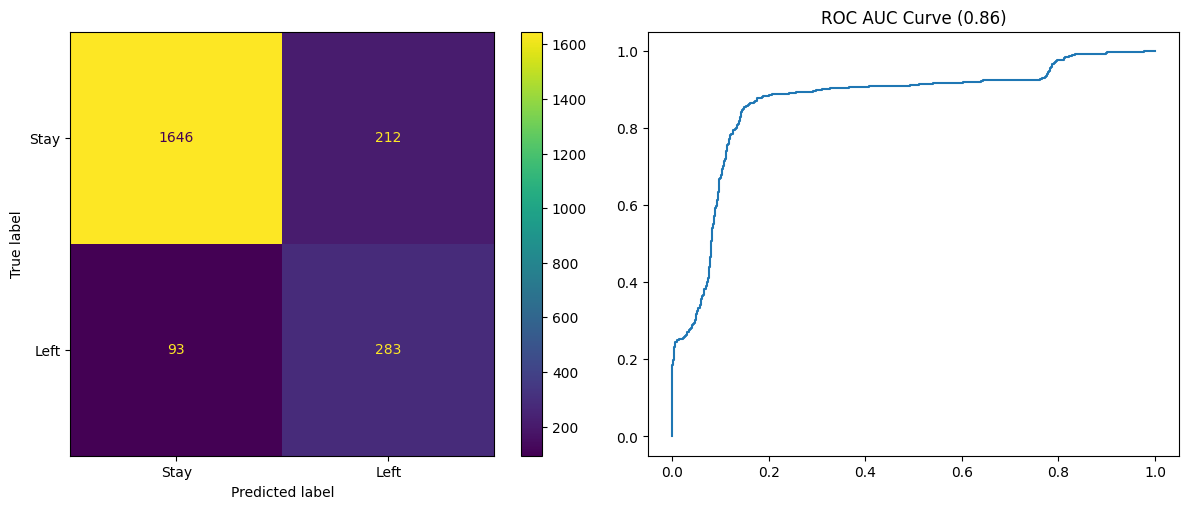

In [126]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_tr, y_tr)
NBReporter(gnb_clf, X_val, y_val).make_report()

In [127]:
test_results.make_test_result("Gaussian Naive Bayes", gnb_clf, X_test, y_test)

,model_name,precision,recall,f1,roc_auc,model
0,Gaussian Naive Bayes,0.568317,0.761273,0.650794,0.860762,GaussianNB()


## Tree Model

### Decision Tree

In [128]:
tree_clf = DecisionTreeClassifier()

param_grid = {
    'max_depth': [3, 4, 6],
    'min_samples_split': [1,2,3],
    'min_samples_leaf': [2, 5, 10]
}

scoring = ['precision', 'recall', 'f1', 'roc_auc']

tree_cv = GridSearchCV(
    tree_clf, 
    param_grid=param_grid, 
    scoring=scoring, 
    cv=5, 
    refit='roc_auc',
    verbose=2
)

In [129]:
%%time
tree_cv.fit(X_tr, y_tr)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=1; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=1; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=1; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=1; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=1; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=3; total time=   0.0s
[CV] END max_depth=3, min_samples_le

c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
45 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'recall', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [130]:
tree_cv.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}


Feature importances: 
                            score
satisfaction_level      0.581976
last_evaluation         0.137297
time_spend_company      0.134336
number_project          0.110321
average_montly_hours    0.035818
salary                  0.000252
work_accident           0.000000
promotion_last_5years   0.000000
department_IT           0.000000
department_RandD        0.000000
department_accounting   0.000000
department_hr           0.000000
department_management   0.000000
department_marketing    0.000000
department_product_mng  0.000000
department_sales        0.000000
department_support      0.000000
department_technical    0.000000
is_overworked           0.000000
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1858
           1       0.96      0.94      0.95       376

    accuracy                           0.98      2234
   macro avg       0.97      0.97      0.97      2234
weighted avg       0.98      0.98      0.98 

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\334076621.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


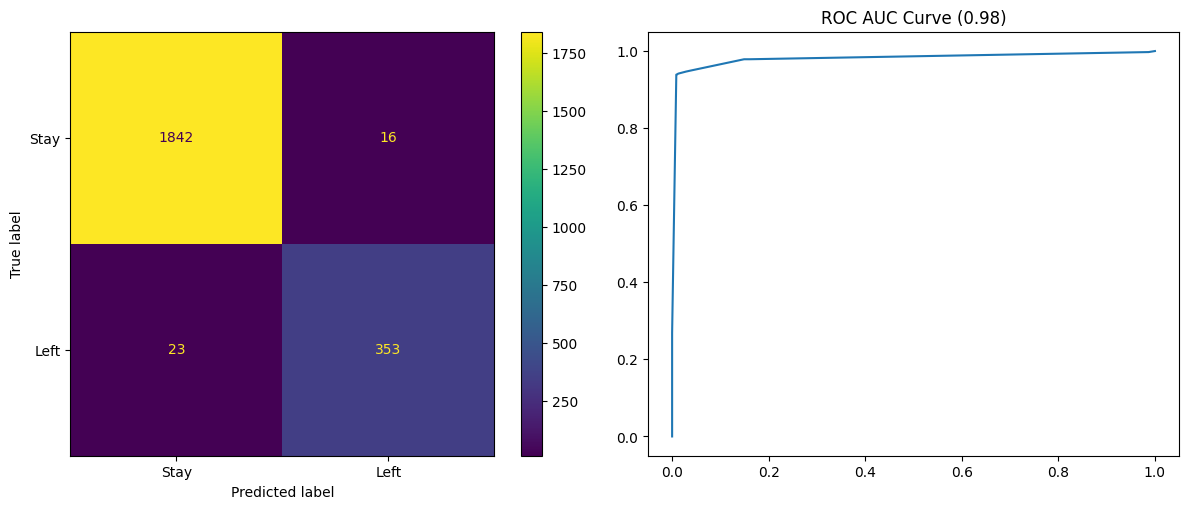

In [131]:
TreeReporter(tree_cv.best_estimator_, X_val, y_val).make_report()

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\2629252241.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


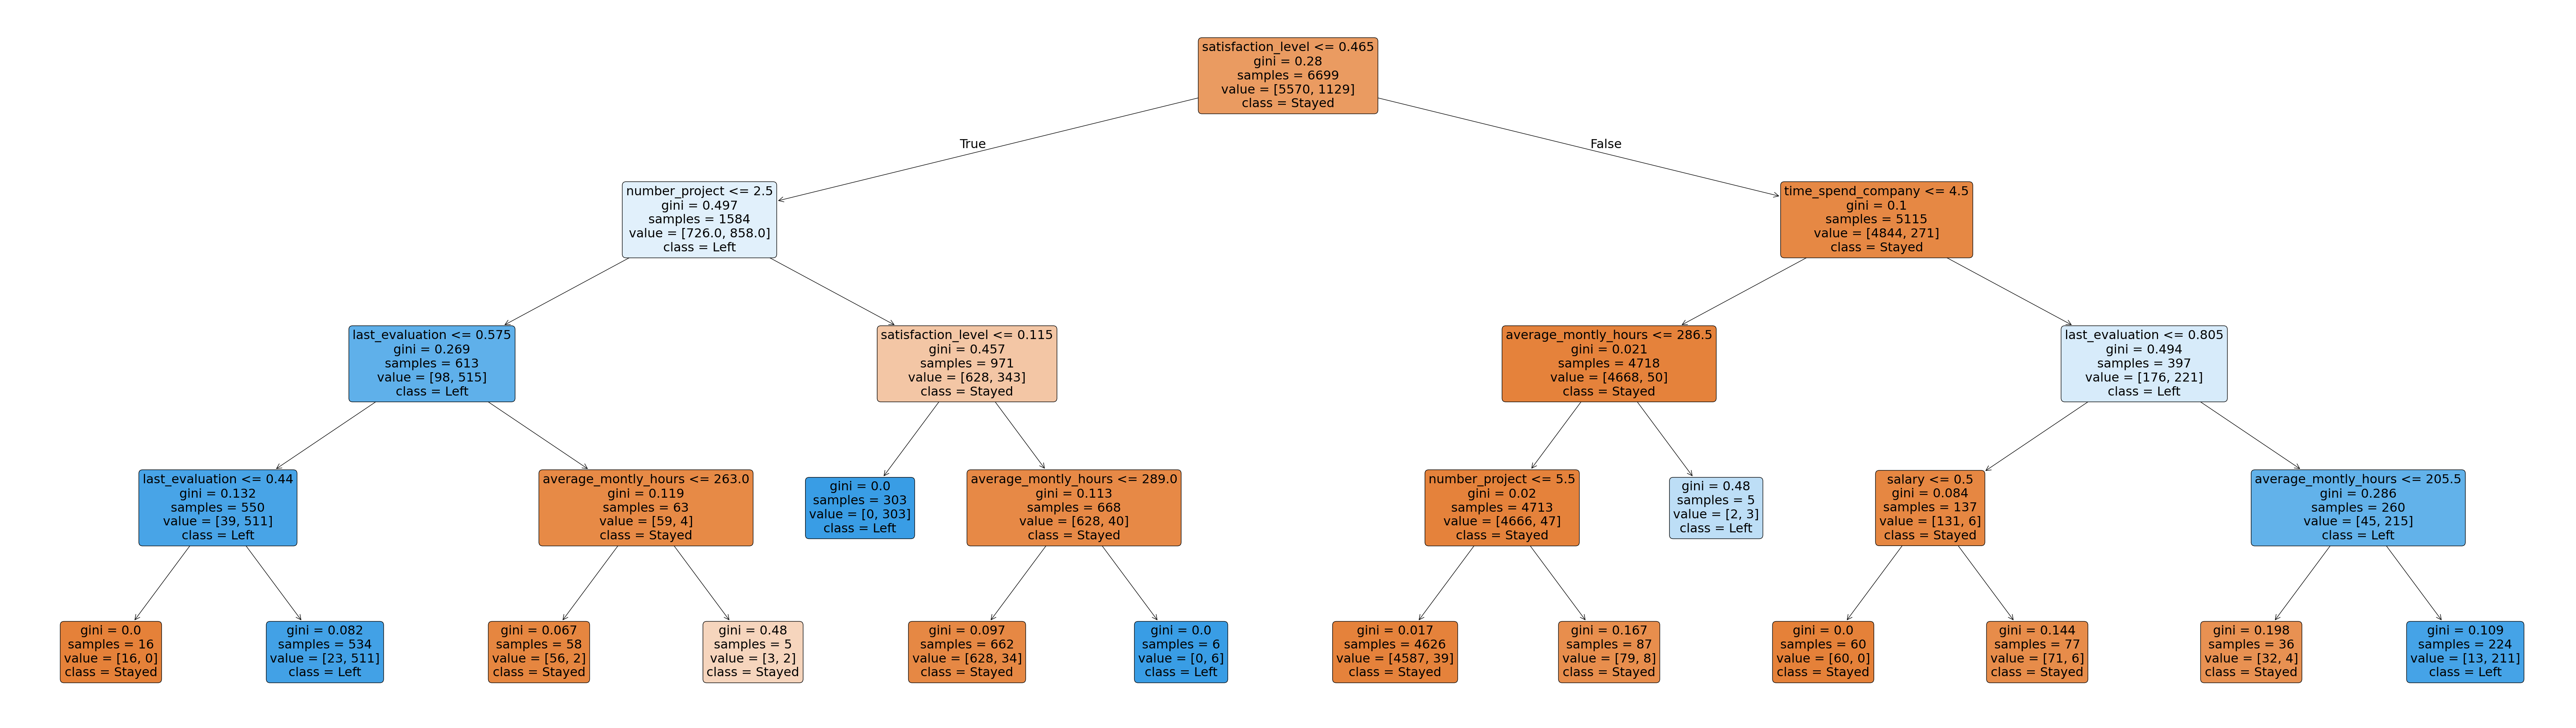

In [132]:
fig, ax = plt.subplots(figsize=(85, 24))
plot_tree(
    tree_cv.best_estimator_, 
    feature_names = X.columns, 
    class_names=['Stayed', 'Left'], 
    max_depth = 5, 
    ax=ax,
    filled=True,
    rounded=True
)
fig.show()

Double click the picture to zoom in

In [133]:
test_results.make_test_result('Decision Tree', tree_cv.best_estimator_, X_test, y_test)

,model_name,precision,recall,f1,roc_auc,model
0,Decision Tree,0.943089,0.923077,0.932976,0.971669,"DecisionTreeClassifier(max_depth=4, min_sample..."


### Random Forest

In [134]:
rf_clf = RandomForestClassifier()

param_grid = {
    'n_estimators': [150, 300],
    'max_depth': [4, 6],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 3],
    'max_samples': [0.7],
    'max_features': [3, 6]
}

scoring = ['f1', 'precision', 'recall', 'roc_auc']

rf_cv = GridSearchCV(
    rf_clf,
    param_grid = param_grid,
    scoring=scoring,
    cv=4,
    refit='roc_auc',
    verbose=2
)

In [135]:
%%time

rf_cv.fit(X_tr, y_tr)

Fitting 4 folds for each of 32 candidates, totalling 128 fits
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.4s
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.2s
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.2s
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.5s
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.5s
[CV] END max_depth=4, max_features=3, max_samples=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.5s
[CV] EN

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6], 'max_features': [3, 6], 'max_samples': [0.7], 'min_samples_leaf': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [136]:
rf_cv.best_params_

{'max_depth': 6,
 'max_features': 6,
 'max_samples': 0.7,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 300}


Feature importances: 
                            score
satisfaction_level      0.392178
number_project          0.221459
time_spend_company      0.141249
average_montly_hours    0.119030
last_evaluation         0.099333
is_overworked           0.018158
work_accident           0.002946
salary                  0.002853
department_technical    0.000477
department_sales        0.000438
department_support      0.000348
department_RandD        0.000324
department_accounting   0.000255
department_hr           0.000249
department_IT           0.000206
department_product_mng  0.000158
department_marketing    0.000155
department_management   0.000135
promotion_last_5years   0.000047
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1858
           1       0.98      0.93      0.95       376

    accuracy                           0.98      2234
   macro avg       0.98      0.96      0.97      2234
weighted avg       0.98      0.98      0.98 

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\334076621.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


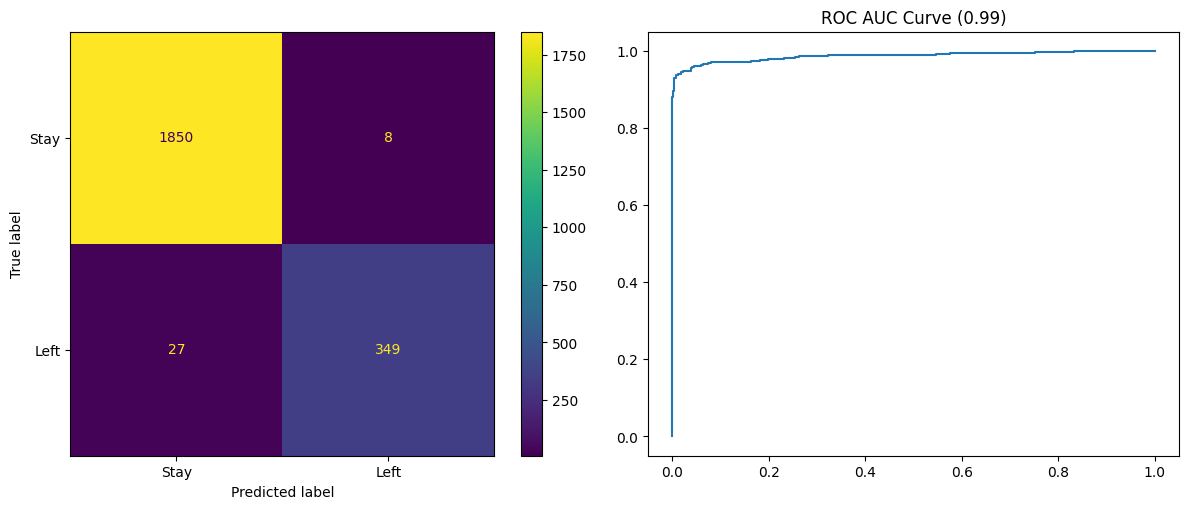

In [137]:
TreeReporter(rf_cv.best_estimator_, X_val, y_val).make_report()

In [138]:
test_results.make_test_result('Random Forest', rf_cv.best_estimator_, X_test, y_test)

,model_name,precision,recall,f1,roc_auc,model
0,Random Forest,0.971751,0.912467,0.941176,0.98111,"(DecisionTreeClassifier(max_depth=6, max_featu..."


### XGBoost

In [139]:
xgb_clf = XGBClassifier(objective='binary:logistic')

param_grid = {
    'max_depth': [2, 4],
    'max_leaves': [1, 2],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.7]
}

scoring = ['f1', 'roc_auc', 'precision', 'recall']

xgb_cv = GridSearchCV(
    xgb_clf,
    param_grid = param_grid,
    scoring=scoring,
    cv = 4,
    refit='roc_auc',
    verbose=2
)

In [140]:
%%time

xgb_cv.fit(X_tr, y_tr)

Fitting 4 folds for each of 8 candidates, totalling 32 fits
[CV] END learning_rate=0.1, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Pr

[CV] END learning_rate=0.1, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.1, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.1, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.1, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.3, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.3, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=2, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=2, max_leaves=2, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.3, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s


c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Project\portfolio\Project\Data Analysis\Salifort Motors - Employee Turnover Analysis and Classification\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV] END learning_rate=0.3, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=4, max_leaves=1, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.0s
[CV] END learning_rate=0.3, max_depth=4, max_leaves=2, subsample=0.7; total time=   0.0s
CPU times: total: 38.8 s
Wall time: 3.9 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.3], 'max_depth': [2, 4], 'max_leaves': [1, 2], 'subsample': [0.7]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1', 'roc_auc', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [141]:
xgb_cv.best_params_

{'learning_rate': 0.3, 'max_depth': 2, 'max_leaves': 2, 'subsample': 0.7}


Feature importances: 
                            score
number_project          0.286201
satisfaction_level      0.253715
time_spend_company      0.195951
last_evaluation         0.083517
work_accident           0.076640
average_montly_hours    0.069232
salary                  0.034744
promotion_last_5years   0.000000
department_IT           0.000000
department_RandD        0.000000
department_accounting   0.000000
department_hr           0.000000
department_management   0.000000
department_marketing    0.000000
department_product_mng  0.000000
department_sales        0.000000
department_support      0.000000
department_technical    0.000000
is_overworked           0.000000
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1858
           1       0.93      0.80      0.86       376

    accuracy                           0.96      2234
   macro avg       0.94      0.89      0.92      2234
weighted avg       0.95      0.96      0.95 

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\334076621.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


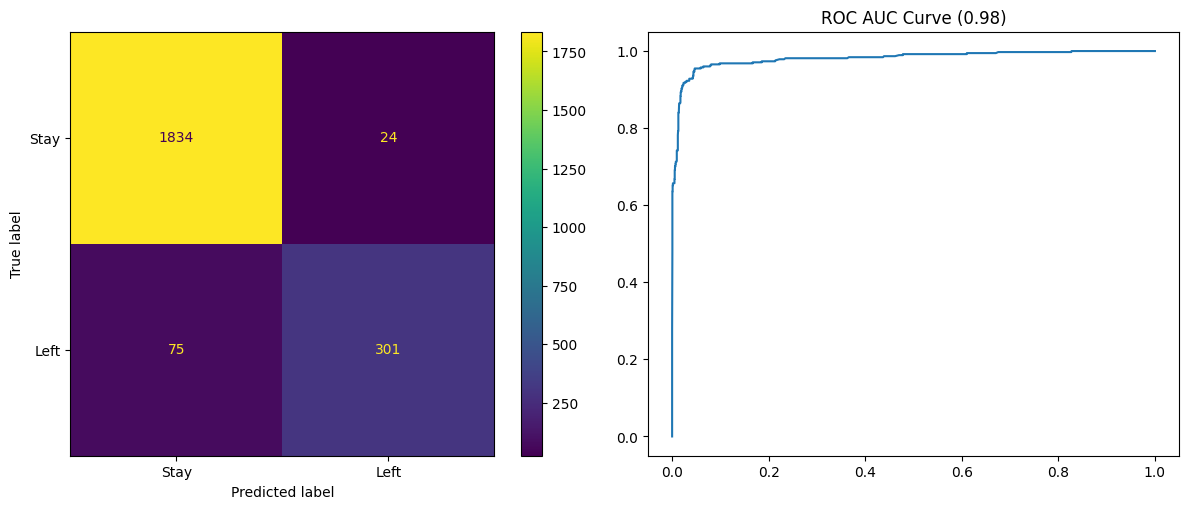

In [142]:
TreeReporter(xgb_cv.best_estimator_, X_val, y_val).make_report()

In [143]:
test_results.make_test_result('XGBoost', xgb_cv.best_estimator_, X_test, y_test)

,model_name,precision,recall,f1,roc_auc,model
0,XGBoost,0.916168,0.811671,0.860759,0.975085,"XGBClassifier(base_score=None, booster=None, c..."


## Result

In [144]:
test_results.results.sort_values(by='roc_auc', ascending=False)

,model_name,precision,recall,f1,roc_auc,model
3,Random Forest,0.971751,0.912467,0.941176,0.98111,"(DecisionTreeClassifier(max_depth=6, max_featu..."
4,XGBoost,0.916168,0.811671,0.860759,0.975085,"XGBClassifier(base_score=None, booster=None, c..."
2,Decision Tree,0.943089,0.923077,0.932976,0.971669,"DecisionTreeClassifier(max_depth=4, min_sample..."
0,Logistic Regression,0.489691,0.251989,0.33275,0.891394,LogisticRegression(max_iter=1000)
1,Gaussian Naive Bayes,0.568317,0.761273,0.650794,0.860762,GaussianNB()


In [145]:
cols = X.columns.tolist()

# Linear Feature Importance
res_model = test_results.results.set_index('model_name')

logres = res_model.loc["Logistic Regression"].model
logres_val = pd.DataFrame([logres.coef_[0].tolist()], columns=cols, index=['Logistic Regression'])

nb = res_model.loc["Gaussian Naive Bayes"].model
nb_val = pd.DataFrame([permutation_importance(nb, X_test, y_test).importances_mean.tolist()], columns=cols, index=['Gaussian Naive Bayes'])

dtree = res_model.loc["Decision Tree"].model
dtree_val = pd.DataFrame([dtree.feature_importances_], index=['Decision Tree'], columns=cols)

rf_tree = res_model.loc["Random Forest"].model
rf_tree_val = pd.DataFrame([rf_tree.feature_importances_], index=['Random Forest'], columns=cols)

xgb_tree = res_model.loc["Decision Tree"].model
xgb_tree_val = pd.DataFrame([xgb_tree.feature_importances_], index=['XGBoost'], columns=cols)

feature_importances = pd.concat([logres_val, nb_val, dtree_val, rf_tree_val, xgb_tree_val], axis=0)
feature_importances = feature_importances.reindex(test_results.results.sort_values(by='roc_auc', ascending=False).model_name)
feature_importances

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,is_overworked
model_name,,,,,,,,,,,,,,,,,,,
Random Forest,0.392178,0.099333,0.221459,0.119030,0.141249,0.002946,0.000047,0.002853,0.000206,0.000324,0.000255,0.000249,0.000135,0.000155,0.000158,0.000438,0.000348,0.000477,0.018158
XGBoost,0.581976,0.137297,0.110321,0.035818,0.134336,0.000000,0.000000,0.000252,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Decision Tree,0.581976,0.137297,0.110321,0.035818,0.134336,0.000000,0.000000,0.000252,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Logistic Regression,-4.465032,0.003025,-0.453960,0.004193,0.963374,-1.327669,-0.471945,-0.516551,-0.152079,-0.616852,-0.167157,0.134526,-0.012348,-0.056927,-0.104470,0.045665,0.065307,0.089032,-0.090086
Gaussian Naive Bayes,0.056401,0.002328,0.049329,0.005461,0.036974,0.013787,0.001432,0.009132,-0.000985,-0.001701,-0.000448,0.001343,0.000537,-0.000090,-0.000985,0.000985,0.000090,0.001074,0.000716


Feature Importances across model

In [146]:
feature_importance_normalized = feature_importances.abs()
feature_importance_normalized = feature_importance_normalized.apply(lambda x: x / feature_importance_normalized.sum(axis=1), axis=0)
feature_importance_normalized.sum(axis=1) # Make sure the total score is one for each model

model_name
Random Forest           1.0
XGBoost                 1.0
Decision Tree           1.0
Logistic Regression     1.0
Gaussian Naive Bayes    1.0
dtype: float64

C:\Users\ASUS F1504ZA\AppData\Local\Temp\ipykernel_8000\1679350895.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


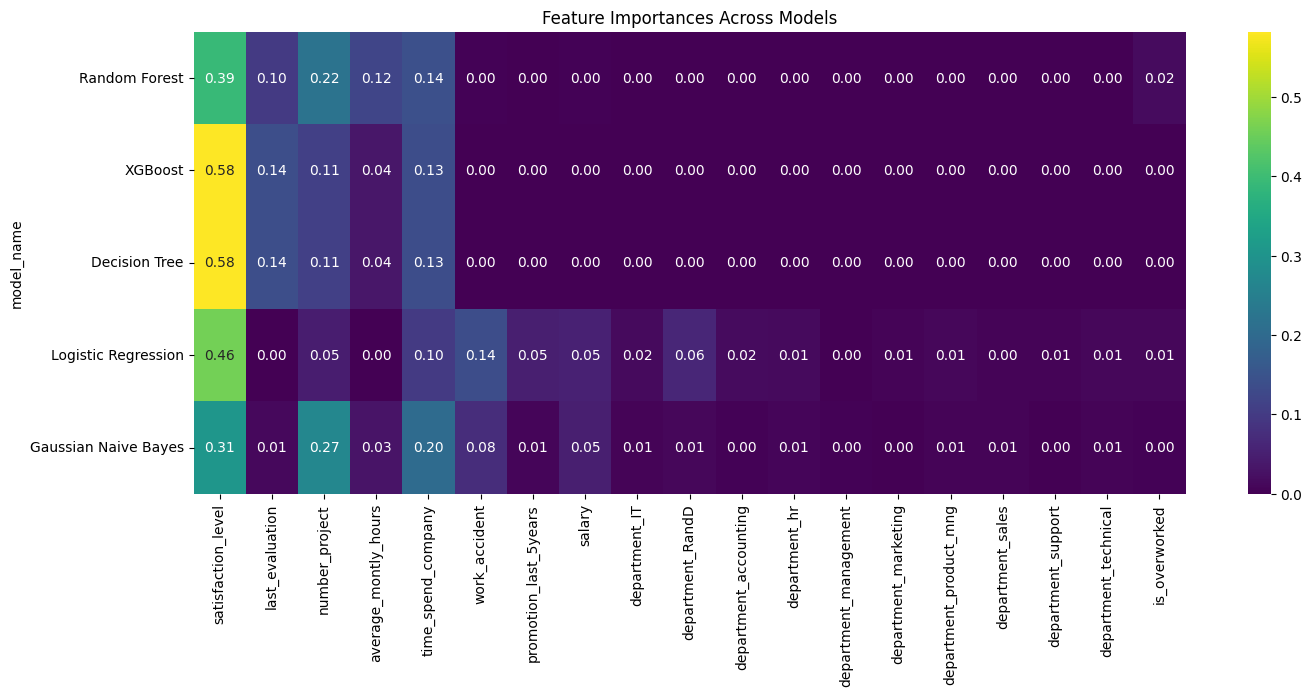

In [147]:
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(feature_importance_normalized, cmap='viridis', annot=True, fmt='.2f', ax=ax)

ax.set_title('Feature Importances Across Models')
fig.show()

Many models agree that the most important features in determining employee turnover are:
1. satisfaction_level
2. number_project
3. time_spend_company
4. last_evaluation

While average_monthly_hours is not universally rated highly across all models, it's linearly correlated with `number_project

# Conclusion & Recommendation

#### Conclusion:

The models and the feature importances extracted from the models confirm that employees at the company are overworked. 

#### Recommendations:

* Cap the number of projects that employees can work on.
* Consider promoting employees who have been with the company for atleast four years, or conduct further investigation about why four-year tenured employees are so dissatisfied. 
* Either reward employees for working longer hours, or don't require them to do so. 
* If employees aren't familiar with the company's overtime pay policies, inform them about this. If the expectations around workload and time off aren't explicit, make them clear. 
* Hold company-wide and within-team discussions to understand and address the company work culture, across the board and in specific contexts. 
* High evaluation scores should not be reserved for employees who work 200+ hours per month. Consider a proportionate scale for rewarding employees who contribute more/put in more effort. 